<a href="https://colab.research.google.com/github/PiyaliChoudhury/Smart-Parking-System/blob/main/smart_parking_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing and Importing Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib xgboost lightgbm catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier


## Generate Structured Parking Dataset (SRM Scenario)
Rules embedded in data:
- Peak hours (8–11, 16–19) → more occupied
- Event days → more occupied
- Near gate → fills faster
- Staff parking → earlier occupancy
These patterns allow ML models to learn effectively.

In [ ]:

zones = ['P1','P2','P3','P4','P5']
data=[]

for zone in zones:
    for pillar in range(1,100):
        for slot in range(1,10):

            hour=np.random.randint(0,24)
            day=np.random.randint(0,7)
            rain=np.random.choice([0,1])
            event=np.random.choice([0,1],p=[0.85,0.15])
            distance=np.random.randint(10,600)

            vehicle=np.random.choice(['Car','Bike'])
            user=np.random.choice(['Student','Staff','Visitor'])

            peak = 1 if (8<=hour<=11 or 16<=hour<=19) else 0
            weekend = 1 if day>=5 else 0

            # Realistic occupancy rule
            score = (
                peak*2 +
                event*3 +
                (distance<150)*2 +
                (user=='Staff')*1 +
                (vehicle=='Car')*1 +
                rain*1
            )

            status = 1 if score>=4 else 0

            data.append([zone,pillar,slot,hour,day,vehicle,user,rain,event,distance,peak,weekend,status])

columns=[
"Zone","Pillar","Slot_Number","Hour","Day",
"Vehicle_Type","User_Type","Rain","Event_Day",
"Distance_from_gate","Peak_Hour","Weekend","Status"
]

df=pd.DataFrame(data,columns=columns)
print("Dataset Size:",df.shape)
df.head()


Dataset Size: (4455, 13)


,Zone,Pillar,Slot_Number,Hour,Day,Vehicle_Type,User_Type,Rain,Event_Day,Distance_from_gate,Peak_Hour,Weekend,Status
0,P1,1,1,8,6,Car,Student,1,0,539,1,1,1
1,P1,1,2,13,1,Bike,Visitor,0,0,581,0,0,0
2,P1,1,3,14,5,Car,Student,0,0,26,0,1,0
3,P1,1,4,17,3,Car,Visitor,1,0,56,1,0,1
4,P1,1,5,5,5,Bike,Visitor,0,0,203,0,1,0


## Encode Categorical Features

In [ ]:

le=LabelEncoder()

for col in ["Zone","Vehicle_Type","User_Type"]:
    df[col]=le.fit_transform(df[col])


## Train Test Split

In [ ]:

X=df.drop("Status",axis=1)
y=df["Status"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


## Logistic Regression

In [ ]:

model_log=LogisticRegression(max_iter=2000)
model_log.fit(X_train,y_train)

pred_log=model_log.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,pred_log))


Logistic Regression Accuracy: 0.9090909090909091


## Naive Bayes

In [ ]:

model_nb=GaussianNB()
model_nb.fit(X_train,y_train)

pred_nb=model_nb.predict(X_test)
print("Naive Bayes Accuracy:",accuracy_score(y_test,pred_nb))


Naive Bayes Accuracy: 0.8799102132435466


## Decision Tree

In [ ]:

model_dt=DecisionTreeClassifier()
model_dt.fit(X_train,y_train)

pred_dt=model_dt.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,pred_dt))


Decision Tree Accuracy: 0.9988776655443322


## Random Forest

In [ ]:

model_rf=RandomForestClassifier(n_estimators=300)
model_rf.fit(X_train,y_train)

pred_rf=model_rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,pred_rf))


Random Forest Accuracy: 1.0


## Gradient Boosting

In [ ]:

model_gb=GradientBoostingClassifier()
model_gb.fit(X_train,y_train)

pred_gb=model_gb.predict(X_test)
print("Gradient Boost Accuracy:",accuracy_score(y_test,pred_gb))


Gradient Boost Accuracy: 1.0


## XGBoost

In [ ]:

model_xgb=XGBClassifier(use_label_encoder=False,eval_metric='logloss')
model_xgb.fit(X_train,y_train)

pred_xgb=model_xgb.predict(X_test)
print("XGBoost Accuracy:",accuracy_score(y_test,pred_xgb))


XGBoost Accuracy: 0.9988776655443322


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:50:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## LightGBM

In [ ]:

model_lgb=lgb.LGBMClassifier()
model_lgb.fit(X_train,y_train)

pred_lgb=model_lgb.predict(X_test)
print("LightGBM Accuracy:",accuracy_score(y_test,pred_lgb))


[LightGBM] [Info] Number of positive: 1256, number of negative: 2308
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 419
[LightGBM] [Info] Number of data points in the train set: 3564, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.352413 -> initscore=-0.608449
[LightGBM] [Info] Start training from score -0.608449
LightGBM Accuracy: 0.9988776655443322


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## CatBoost

In [ ]:

model_cat=CatBoostClassifier(verbose=0)
model_cat.fit(X_train,y_train)

pred_cat=model_cat.predict(X_test)
print("CatBoost Accuracy:",accuracy_score(y_test,pred_cat))


CatBoost Accuracy: 1.0


## Model Accuracy Comparison Graph

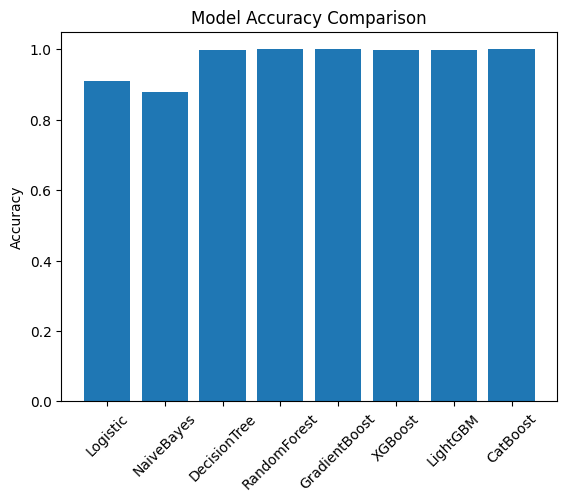

In [ ]:

models=['Logistic','NaiveBayes','DecisionTree','RandomForest','GradientBoost','XGBoost','LightGBM','CatBoost']
scores=[
accuracy_score(y_test,pred_log),
accuracy_score(y_test,pred_nb),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_gb),
accuracy_score(y_test,pred_xgb),
accuracy_score(y_test,pred_lgb),
accuracy_score(y_test,pred_cat)
]

plt.figure()
plt.bar(models,scores)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


## Confusion Matrix


In [ ]:
pred = model_rf.predict(X_test)

In [ ]:
pred = model_log.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

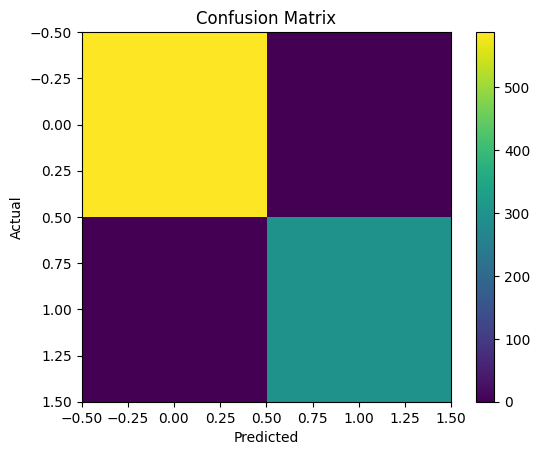

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

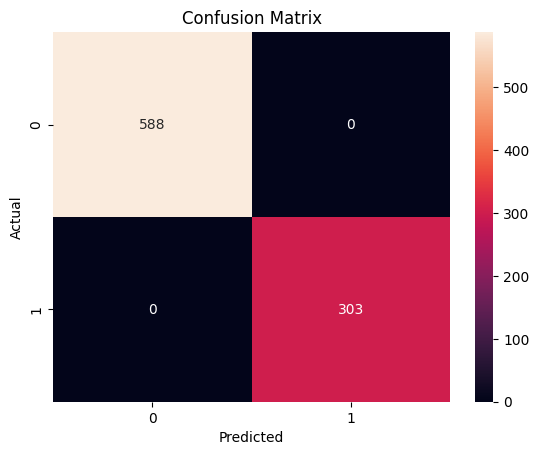

In [ ]:
import seaborn as sns

pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Parking Occupancy

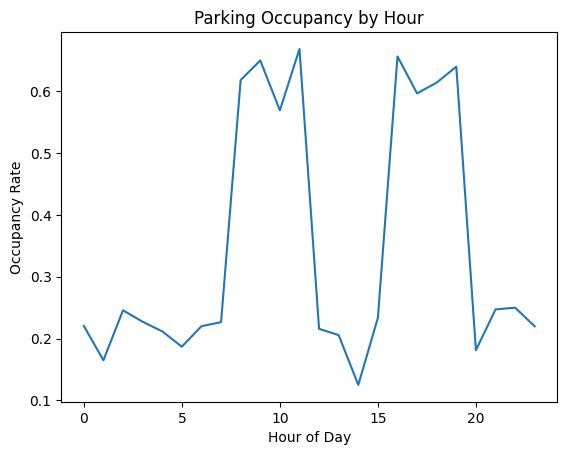

In [ ]:
hour_usage = df.groupby("Hour")["Status"].mean()

plt.figure()

plt.plot(hour_usage.index, hour_usage.values)

plt.title("Parking Occupancy by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Occupancy Rate")

plt.show()

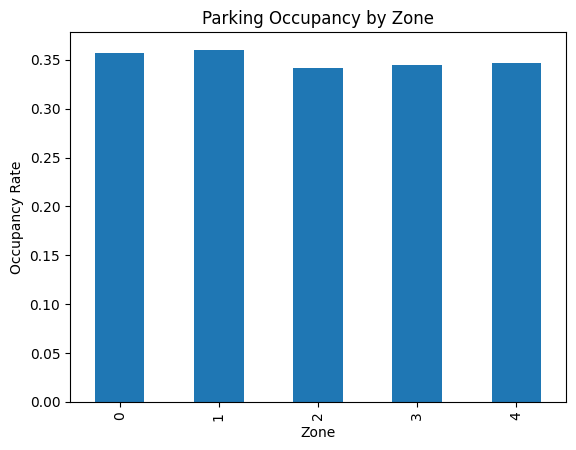

In [ ]:
zone_usage = df.groupby("Zone")["Status"].mean()

plt.figure()

zone_usage.plot(kind="bar")

plt.title("Parking Occupancy by Zone")

plt.xlabel("Zone")

plt.ylabel("Occupancy Rate")

plt.show()

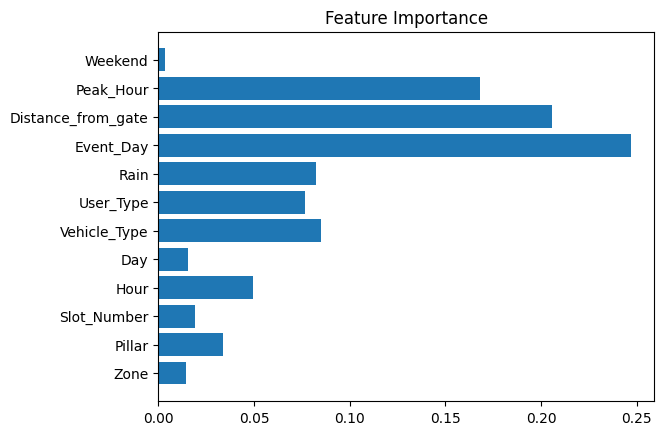

In [ ]:
importance = model_rf.feature_importances_

features = X.columns

plt.figure()

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

## Parking Demand Heatmap (Hour vs Day)

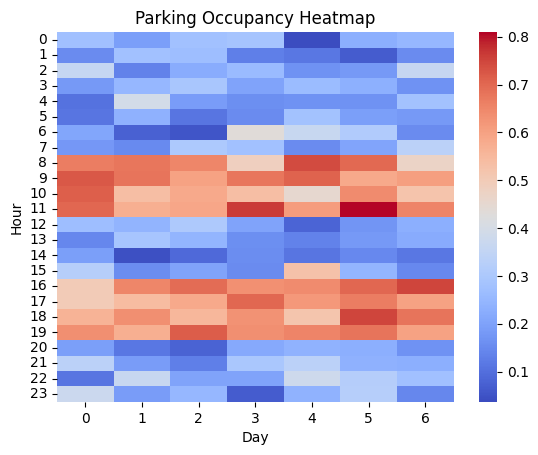

In [ ]:
import seaborn as sns

heat = df.pivot_table(
    values="Status",
    index="Hour",
    columns="Day",
    aggfunc="mean"
)

plt.figure()

sns.heatmap(heat, cmap="coolwarm")

plt.title("Parking Occupancy Heatmap")

plt.show()

## Model Accuracy Comparison Graph

In [ ]:
from sklearn.metrics import accuracy_score

# Logistic Regression
pred_log = model_log.predict(X_test)
acc_log = accuracy_score(y_test, pred_log)

# Naive Bayes
pred_nb = model_nb.predict(X_test)
acc_nb = accuracy_score(y_test, pred_nb)

# Decision Tree
pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

# Random Forest
pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

# XGBoost
pred_xgb = model_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)

print("Logistic Accuracy:", acc_log)
print("Naive Bayes Accuracy:", acc_nb)
print("Decision Tree Accuracy:", acc_dt)
print("Random Forest Accuracy:", acc_rf)
print("XGBoost Accuracy:", acc_xgb)

Logistic Accuracy: 0.9090909090909091
Naive Bayes Accuracy: 0.8799102132435466
Decision Tree Accuracy: 0.9988776655443322
Random Forest Accuracy: 1.0
XGBoost Accuracy: 0.9988776655443322


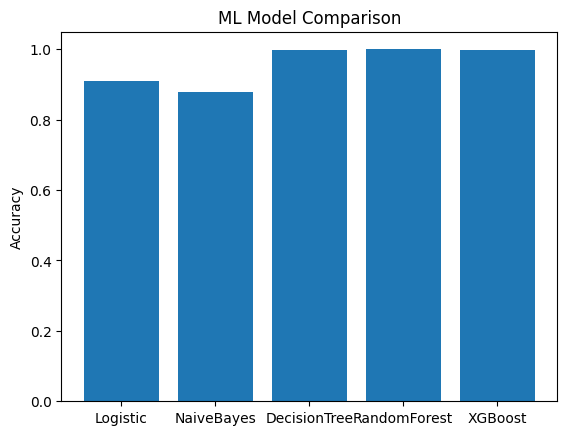

In [ ]:
models = [
"Logistic",
"NaiveBayes",
"DecisionTree",
"RandomForest",
"XGBoost"
]

scores = [
acc_log,
acc_nb,
acc_dt,
acc_rf,
acc_xgb
]

plt.figure()

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("ML Model Comparison")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Random Forest Metrics")

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Random Forest Metrics
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
df["Temperature"] = np.random.randint(20,40,len(df))

df["Traffic_Level"] = np.random.randint(0,10,len(df))

df["Exam_Day"] = np.random.choice([0,1],len(df))

df["Festival_Day"] = np.random.choice([0,1],len(df))

df["EV_Vehicle"] = np.random.choice([0,1],len(df))

df["Vehicle_Size"] = np.random.choice([1,2,3],len(df))

In [ ]:
X = df.drop("Status", axis=1)

y = df["Status"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

## Deep Learning Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_dl = Sequential()

model_dl.add(Dense(128, activation="relu", input_dim=X_train.shape[1]))

model_dl.add(Dropout(0.3))

model_dl.add(Dense(64, activation="relu"))

model_dl.add(Dense(32, activation="relu"))

model_dl.add(Dense(1, activation="sigmoid"))

model_dl.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_dl = Sequential()

model_dl.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
model_dl.add(Dropout(0.3))

model_dl.add(Dense(64, activation='relu'))
model_dl.add(Dropout(0.2))

model_dl.add(Dense(32, activation='relu'))

model_dl.add(Dense(1, activation='sigmoid'))

model_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model_dl.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7096 - loss: 0.5248 - val_accuracy: 0.8979 - val_loss: 0.2802
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8833 - loss: 0.2680 - val_accuracy: 0.9169 - val_loss: 0.1758
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9094 - loss: 0.2142 - val_accuracy: 0.9237 - val_loss: 0.1585
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9102 - loss: 0.2016 - val_accuracy: 0.9360 - val_loss: 0.1523
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.1857 - val_accuracy: 0.9315 - val_loss: 0.1460
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9223 - loss: 0.1723 - val_accuracy: 0.9371 - val_loss: 0.1423
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9301 - loss: 0.1555 - val_accuracy: 0.9484 - val_loss: 0.1298
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9360 - loss: 0.1492 - val_accuracy: 0.9517 -

## Plot Training vs Validation Accuracy

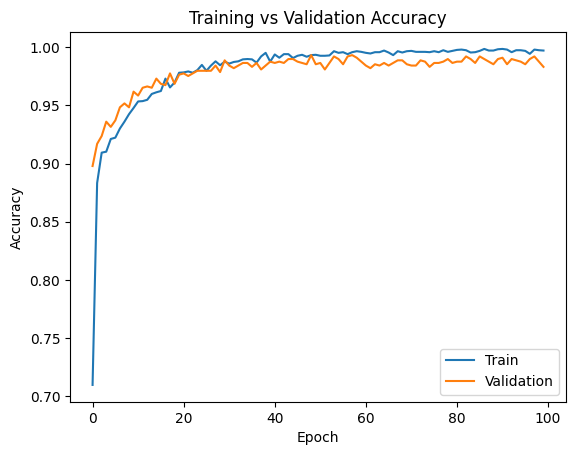

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Plot Loss Curve

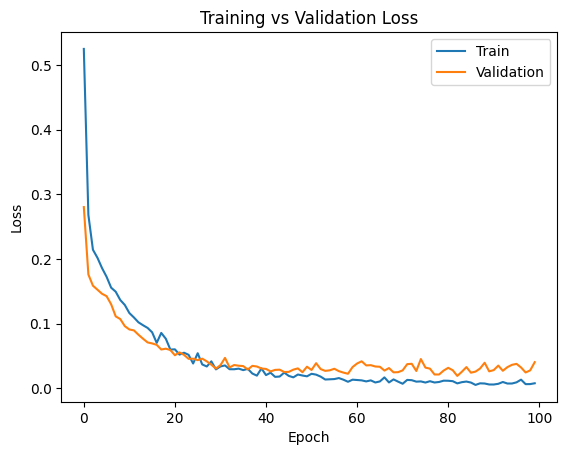

In [ ]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
pred_dl = (model_dl.predict(X_test_scaled) > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, pred_dl))
print("Precision:", precision_score(y_test, pred_dl))
print("Recall:", recall_score(y_test, pred_dl))
print("F1 Score:", f1_score(y_test, pred_dl))

Accuracy: 0.9831649831649831
Precision: 0.9615384615384616
Recall: 0.9900990099009901
F1 Score: 0.975609756097561


## Confusion Matrix for Deep Learning

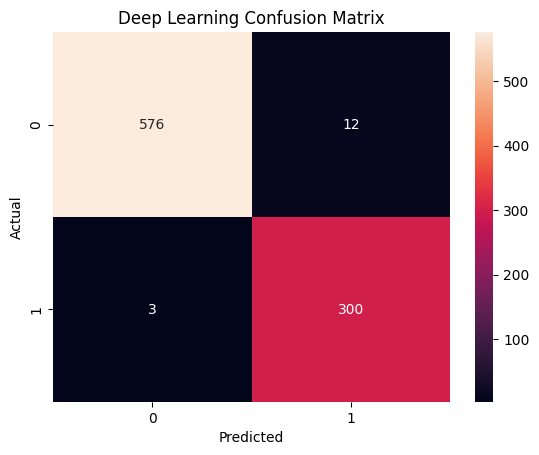

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_dl)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Deep Learning Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Early Stopping (to prevent overfitting)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10
)

In [ ]:
history = model_dl.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9972 - loss: 0.0063 - val_accuracy: 0.9888 - val_loss: 0.0346
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9978 - loss: 0.0051 - val_accuracy: 0.9865 - val_loss: 0.0292
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.9921 - val_loss: 0.0298
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9865 - val_loss: 0.0285
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9989 - loss: 0.0057 - val_accuracy: 0.9921 - val_loss: 0.0187
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9978 - loss: 0.0053 - val_accuracy: 0.9910 - val_loss: 0.0200
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9986 - loss: 0.0045 - val_accuracy: 0.9933 - val_loss: 0.0168
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9980 - loss: 0.0054 - val_accuracy: 0.9888 - v

In [ ]:
df["Month"] = np.random.randint(1,13,len(df))
df["Week_Number"] = np.random.randint(1,52,len(df))
df["Peak_Hour"] = df["Hour"].apply(lambda x: 1 if (8<=x<=11 or 16<=x<=19) else 0)
df["Weekend"] = df["Day"].apply(lambda x: 1 if x>=5 else 0)
df["Exam_Day"] = np.random.choice([0,1],len(df))
df["Holiday"] = np.random.choice([0,1],len(df))
print("Dataset Shape:", df.shape)
print(df.head(10))
print("Features in dataset:")
print(df.columns)

Dataset Shape: (4455, 22)
   Zone  Pillar  Slot_Number  Hour  Day  Vehicle_Type  User_Type  Rain  \
0     0       1            1     8    6             1          1     1   
1     0       1            2    13    1             0          2     0   
2     0       1            3    14    5             1          1     0   
3     0       1            4    17    3             1          2     1   
4     0       1            5     5    5             0          2     0   
5     0       1            6     9    5             0          2     1   
6     0       1            7     5    5             0          0     0   
7     0       1            8    15    6             1          1     1   
8     0       1            9    17    5             1          1     1   
9     0       2            1     6    0             1          1     1   

   Event_Day  Distance_from_gate  ...  Status  Temperature  Traffic_Level  \
0          0                 539  ...       1           21              2   
1    

In [ ]:
print(df.describe())

              Zone       Pillar  Slot_Number         Hour          Day  \
count  4455.000000  4455.000000  4455.000000  4455.000000  4455.000000   
mean      2.000000    50.000000     5.000000    11.425365     3.004040   
std       1.414372    28.580588     2.582279     6.894857     2.000782   
min       0.000000     1.000000     1.000000     0.000000     0.000000   
25%       1.000000    25.000000     3.000000     5.000000     1.000000   
50%       2.000000    50.000000     5.000000    11.000000     3.000000   
75%       3.000000    75.000000     7.000000    17.000000     5.000000   
max       4.000000    99.000000     9.000000    23.000000     6.000000   

       Vehicle_Type    User_Type         Rain    Event_Day  \
count   4455.000000  4455.000000  4455.000000  4455.000000   
mean       0.503704     0.988328     0.495174     0.147475   
std        0.500042     0.815129     0.500033     0.354618   
min        0.000000     0.000000     0.000000     0.000000   
25%        0.000000    

## Count Free vs Occupied Parking

In [ ]:
print(df["Status"].value_counts())

Status
0    2896
1    1559
Name: count, dtype: int64


In [ ]:
print("Total Features:", len(df.columns))

Total Features: 22


In [ ]:
print(df.isnull().sum())

Zone                  0
Pillar                0
Slot_Number           0
Hour                  0
Day                   0
Vehicle_Type          0
User_Type             0
Rain                  0
Event_Day             0
Distance_from_gate    0
Peak_Hour             0
Weekend               0
Status                0
Temperature           0
Traffic_Level         0
Exam_Day              0
Festival_Day          0
EV_Vehicle            0
Vehicle_Size          0
Month                 0
Week_Number           0
Holiday               0
dtype: int64


In [ ]:
print(df.sample(5))

      Zone  Pillar  Slot_Number  Hour  Day  Vehicle_Type  User_Type  Rain  \
601      0      67            8    14    3             1          0     0   
2021     2      27            6    19    3             0          2     1   
2616     2      93            7     7    5             1          0     0   
2245     2      52            5     5    0             0          0     0   
1402     1      57            8     5    6             1          1     0   

      Event_Day  Distance_from_gate  ...  Status  Temperature  Traffic_Level  \
601           0                 233  ...       0           25              0   
2021          0                 307  ...       0           25              2   
2616          0                 402  ...       0           33              0   
2245          0                 126  ...       0           38              2   
1402          0                 337  ...       0           35              1   

      Exam_Day  Festival_Day  EV_Vehicle  Vehicle_Size  

## Correlation Matrix


In [ ]:
print(df.corr())

                            Zone        Pillar   Slot_Number      Hour  \
Zone                1.000000e+00 -2.015840e-16  3.952626e-15 -0.003615   
Pillar             -2.015840e-16  1.000000e+00  5.343357e-17 -0.002273   
Slot_Number         3.952626e-15  5.343357e-17  1.000000e+00 -0.005889   
Hour               -3.614602e-03 -2.272983e-03 -5.888956e-03  1.000000   
Day                -1.475704e-02  6.851322e-03  1.216760e-02 -0.016742   
Vehicle_Type       -1.015849e-02 -7.147978e-03 -1.721373e-02 -0.009737   
User_Type           7.010715e-03  1.696153e-03 -3.050609e-02 -0.021248   
Rain                1.619040e-02  8.923361e-03 -2.260432e-03 -0.015652   
Event_Day          -1.701016e-02 -1.333564e-02  2.206622e-03  0.002437   
Distance_from_gate -1.391913e-02  1.057622e-02 -1.339398e-02  0.009069   
Peak_Hour          -6.725004e-04  1.218053e-02 -2.136393e-02  0.215340   
Weekend            -2.663905e-02  4.509943e-03  2.438201e-02 -0.004008   
Status             -1.064909e-02 -3.57

In [ ]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (3564, 18)
Testing Shape: (891, 18)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(max_iter=2000)

model_log.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

model_nb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()

model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=300)

model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

model_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:51:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
pred_log = model_log.predict(X_test_scaled)

pred_nb = model_nb.predict(X_test_scaled)

pred_dt = model_dt.predict(X_test)

pred_rf = model_rf.predict(X_test)

pred_xgb = model_xgb.predict(X_test)

In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_dl = Sequential()

model_dl.add(Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)))

model_dl.add(Dropout(0.3))

model_dl.add(Dense(64, activation="relu"))

model_dl.add(Dense(32, activation="relu"))

model_dl.add(Dense(1, activation="sigmoid"))

model_dl.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model_dl.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7758 - loss: 0.4797 - val_accuracy: 0.8945 - val_loss: 0.2483
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8791 - loss: 0.2592 - val_accuracy: 0.9102 - val_loss: 0.1848
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9060 - loss: 0.2116 - val_accuracy: 0.9226 - val_loss: 0.1725
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9125 - loss: 0.1933 - val_accuracy: 0.9315 - val_loss: 0.1594
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9237 - loss: 0.1703 - val_accuracy: 0.9360 - val_loss: 0.1518
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9343 - loss: 0.1532 - val_accuracy: 0.9405 - val_loss: 0.1337
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9386 - loss: 0.1428 - val_accuracy: 0.9439 - val_loss: 0.1248
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9444 - loss: 0.1295 - val_accuracy: 0.9484 - v

In [ ]:
pred_dl = (model_dl.predict(X_test_scaled) > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, pred_dl))
print("Precision:", precision_score(y_test, pred_dl))
print("Recall:", recall_score(y_test, pred_dl))
print("F1 Score:", f1_score(y_test, pred_dl))

Accuracy: 0.9842873176206509
Precision: 0.9737704918032787
Recall: 0.9801980198019802
F1 Score: 0.9769736842105263


## Real-Time Input Data

In [ ]:
print(X.columns)

Index(['Zone', 'Pillar', 'Slot_Number', 'Hour', 'Day', 'Vehicle_Type',
       'User_Type', 'Rain', 'Event_Day', 'Distance_from_gate', 'Peak_Hour',
       'Weekend', 'Temperature', 'Traffic_Level', 'Exam_Day', 'Festival_Day',
       'EV_Vehicle', 'Vehicle_Size', 'Month', 'Week_Number', 'Holiday'],
      dtype='object')


In [ ]:
new_vehicle = pd.DataFrame({

"Zone":[2],
"Pillar":[35],
"Slot_Number":[5],
"Hour":[10],
"Day":[2],
"Vehicle_Type":[1],
"User_Type":[0],
"Rain":[0],
"Event_Day":[0],
"Distance_from_gate":[120],
"Peak_Hour":[1],
"Weekend":[0],
"Temperature":[30],
"Traffic_Level":[6],
"Exam_Day":[0],
"Festival_Day":[0],
"EV_Vehicle":[0],
"Vehicle_Size":[2],
"Month":[6],
"Week_Number":[25],
"Holiday":[0]

})

In [ ]:
new_vehicle = new_vehicle[X.columns]

In [ ]:
new_vehicle_scaled = scaler.transform(new_vehicle)

In [ ]:
prediction = model_rf.predict(new_vehicle)

print("Parking Slot Prediction:", prediction)

Parking Slot Prediction: [1]


In [ ]:
prediction_dl = (model_dl.predict(new_vehicle_scaled) > 0.5).astype(int)

print("Deep Learning Prediction:", prediction_dl)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Deep Learning Prediction: [[1]]


In [ ]:
new_vehicle = X.iloc[[0]].copy()

new_vehicle[:] = 0

new_vehicle["Zone"] = 2
new_vehicle["Hour"] = 10
new_vehicle["Traffic_Level"] = 6

In [ ]:
prob = model_dl.predict(new_vehicle_scaled)

print("Probability:", prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Probability: [[0.9999964]]


In [ ]:
pred = (model_dl.predict(new_vehicle_scaled) > 0.5).astype(int)

if pred == 0:
    print("Parking Slot Status: AVAILABLE")
else:
    print("Parking Slot Status: OCCUPIED")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Parking Slot Status: OCCUPIED


# City-Level Features

In [ ]:
df["City"] = np.random.choice(
["Chennai","Delhi","Mumbai","Bangalore","Hyderabad","Kolkata"],
len(df)
)

df["City_Tier"] = np.random.choice([1,2,3], len(df))

df["Population_Density"] = np.random.randint(1000,20000,len(df))

df["Traffic_Congestion_Index"] = np.random.uniform(0,1,len(df))

In [ ]:
df["Smart_City_Project"] = np.random.choice([0,1],len(df))

df["Parking_Sensors"] = np.random.randint(0,200,len(df))

df["Digital_Parking_Board"] = np.random.choice([0,1],len(df))

df["Mobile_App_Usage"] = np.random.choice([0,1],len(df))

In [ ]:
df["Parking_Fee"] = np.random.randint(10,200,len(df))

df["Dynamic_Pricing"] = np.random.choice([0,1],len(df))

df["EV_Incentives"] = np.random.choice([0,1],len(df))

df["No_Parking_Zone"] = np.random.choice([0,1],len(df))

In [ ]:
df["Metro_Access"] = np.random.choice([0,1],len(df))

df["Bus_Stop_Nearby"] = np.random.choice([0,1],len(df))

df["Public_Transport_Index"] = np.random.uniform(0,1,len(df))

In [ ]:
df["EV_Charging_Stations"] = np.random.randint(0,20,len(df))

df["Green_Parking"] = np.random.choice([0,1],len(df))

df["Carbon_Emission_Level"] = np.random.uniform(0,100,len(df))

In [ ]:
df["Live_Traffic_Score"] = np.random.uniform(0,10,len(df))

df["Navigation_System"] = np.random.choice([0,1],len(df))

df["Parking_Reservation"] = np.random.choice([0,1],len(df))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["City"] = le.fit_transform(df["City"])

In [ ]:
print("New Dataset Shape:", df.shape)

print(df.head())

New Dataset Shape: (4455, 43)
   Zone  Pillar  Slot_Number  Hour  Day  Vehicle_Type  User_Type  Rain  \
0     0       1            1     8    6             1          1     1   
1     0       1            2    13    1             0          2     0   
2     0       1            3    14    5             1          1     0   
3     0       1            4    17    3             1          2     1   
4     0       1            5     5    5             0          2     0   

   Event_Day  Distance_from_gate  ...  No_Parking_Zone  Metro_Access  \
0          0                 539  ...                1             1   
1          0                 581  ...                1             1   
2          0                  26  ...                1             1   
3          0                  56  ...                1             0   
4          0                 203  ...                1             0   

   Bus_Stop_Nearby  Public_Transport_Index  EV_Charging_Stations  \
0                1      

In [ ]:
X = df.drop("Status", axis=1)

y = df["Status"]

In [ ]:
model_rf = RandomForestClassifier(n_estimators=300)

model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [ ]:
pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

Accuracy: 1.0
Precision: 1.0
F1 Score: 1.0


In [ ]:
import joblib

joblib.dump(model_rf,"parking_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
import joblib

joblib.dump(model_rf, "parking_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
print(model_rf)

RandomForestClassifier(n_estimators=300)


In [ ]:
import joblib

joblib.dump(model_rf, "parking_model.pkl")

['parking_model.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'catboost_info', 'parking_model.pkl', 'scaler.pkl', 'sample_data']


In [ ]:
from google.colab import files

files.download("parking_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df["Status"].value_counts())

Status
0    2896
1    1559
Name: count, dtype: int64
